In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc, average_precision_score
)

from config.paths import (
    X_TRAIN, X_TEST, Y_TRAIN, Y_TEST,
    LOGISTIC_REGRESSION_METRICS, LOGISTIC_REGRESSION_MODEL, LOGISTIC_REGRESSION_CHARTS
)

LOGISTIC_REGRESSION_CHARTS.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(X_TRAIN)
X_test = pd.read_csv(X_TEST)
y_train = pd.read_csv(Y_TRAIN).squeeze()
y_test = pd.read_csv(Y_TEST).squeeze()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 7), (2000, 7), (8000,), (2000,))

In [4]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

scoring = ['precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring)

cv_summary = pd.DataFrame({
    metric: [cv_results[f'test_{metric}'].mean(), cv_results[f'test_{metric}'].std()]
    for metric in scoring
}, index=['mean', 'std']).T

print(cv_summary)

                       mean       std
precision          0.137448  0.012002
recall             0.808201  0.088656
f1                 0.234769  0.020350
roc_auc            0.895748  0.032461
average_precision  0.447525  0.059920


In [5]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.83      0.88      2000



In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

test_metrics = {
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_proba),
    'average_precision': average_precision_score(y_test, y_proba),
}

metrics_df = cv_summary.copy()
metrics_df['test'] = [test_metrics[m] for m in metrics_df.index]
metrics_df = metrics_df.rename(columns={'mean': 'cv_mean', 'std': 'cv_std'})

metrics_df.to_csv(LOGISTIC_REGRESSION_METRICS)
metrics_df

,cv_mean,cv_std,test
precision,0.137448,0.012002,0.143959
recall,0.808201,0.088656,0.823529
f1,0.234769,0.020350,0.245077
roc_auc,0.895748,0.032461,0.906886
average_precision,0.447525,0.059920,0.396385


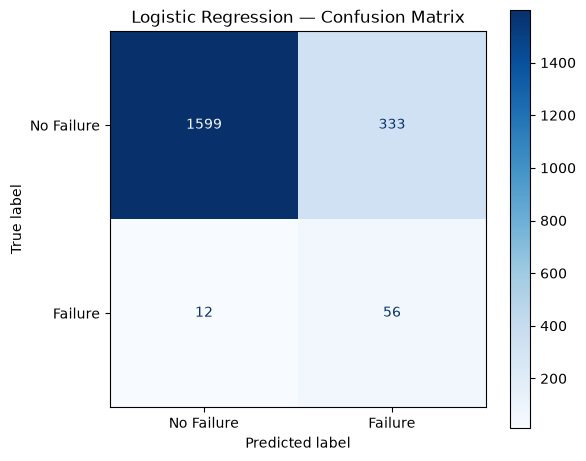

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Failure', 'Failure'])
 
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.savefig(LOGISTIC_REGRESSION_CHARTS / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
